# Modelo de Fidelización y Recompra - Tienda Online Retail II

## 1. Business Understanding

**Dataset:** Online Retail II (2019)  
**Tarea:** Clasificación binaria · `is_rebuyer` o `target` (52.75% positivos)  
**Pipeline:** EDA → Feature Engineering → Split Temporal → Modelado → Evaluación de Negocio → DALEX  
**Objetivo** El objetivo de este proyecto es desarrollar un modelo de Machine Learning capaz de predecir la probabilidad de recompra de los clientes de una empresa retail online.

Desde el punto de vista de negocio, identificar clientes con alta probabilidad de volver a comprar permite:

* Optimizar campañas de fidelización.
* Priorizar acciones comerciales.
* Mejorar la retención de clientes.
* Incrementar el Customer Lifetime Value (CLV).
* Reducir costes de adquisición de nuevos clientes.

Por otro lado, detectar clientes con baja probabilidad de recompra permite diseñar campañas de retención específicas y reducir el churn.

El problema se formula como una tarea de clasificación binaria:

* 1 → el cliente vuelve a comprar.
* 0 → el cliente no vuelve a comprar.

El dataset utilizado contiene transacciones históricas de una empresa de retail online entre 2009 y 2011.


## 2. Data Understanding

¿Qué haremos?

* Carga de datos
* Primeras inspecciones
* calidad del dataset
* Entendimiento de variables

Siendo el objetivo técnico entender:

* Volumen
* Tipos
* Nulos
* Inconsistencias
* Comportamiento general

### 2.0 Entorno y dependencias

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import seaborn as sns

pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 160)
plt.style.use('ggplot')

sns.set_theme(context='notebook', style='whitegrid')
sns.set_palette('husl')

### 2.1 Carga de los datos y primeras inspecciones

In [3]:
# --------------------------------------
# Ruta al dataset
# --------------------------------------
DATA_PATH = r'../data/raw/online_retail_II.xlsx'

xl = pd.ExcelFile(DATA_PATH)

dfs = []
for sheet in xl.sheet_names:
    print(f"Leyendo hoja: {sheet}")
    dfs.append(pd.read_excel(xl, sheet_name=sheet))

df_raw = pd.concat(dfs, ignore_index=True)

Leyendo hoja: Year 2009-2010
Leyendo hoja: Year 2010-2011


In [4]:
# --------------------------------------
# Generar un archivo pickle para acelerar futuras cargas
# --------------------------------------
df_raw.to_pickle('../data/processed/online_retail.pkl')

In [5]:
# --------------------------------------
# Mostrar primeras filas del DataFrame
# --------------------------------------
df_raw.head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
5,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,13085.0,United Kingdom
6,489434,21871,SAVE THE PLANET MUG,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
7,489434,21523,FANCY FONT HOME SWEET HOME DOORMAT,10,2009-12-01 07:45:00,5.95,13085.0,United Kingdom
8,489435,22350,CAT BOWL,12,2009-12-01 07:46:00,2.55,13085.0,United Kingdom
9,489435,22349,"DOG BOWL , CHASING BALL DESIGN",12,2009-12-01 07:46:00,3.75,13085.0,United Kingdom


In [6]:
# --------------------------------------
# Información general del DataFrame
# --------------------------------------
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[ns]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 65.1+ MB


In [7]:
# --------------------------------------
# Mostrar el número de filas y columnas
# --------------------------------------
print(f"Número de filas: {df_raw.shape[0]}")
print(f"Número de columnas: {df_raw.shape[1]}")

Número de filas: 1067371
Número de columnas: 8


### 2.2 Descripción de variables

| Variable | Tipo | Descripción |
| -------- | ----- | ---------- |
| `Invoice` | Nominal | Número de factura. Un número entero de 6 dígitos asignado de forma única a cada transacción. Si este código comienza con la letra "C", indica una cancelación. |
| `StockCode` | Nominal | Código del producto (artículo). Un número entero de 5 dígitos asignado de forma única a cada producto distinto. |
| `Description` | Nominal | Nombre del producto (artículo) |
| `Quantity` | Numérico | Cantidad de cada producto (artículo) por transacción. |
| `InvoiceDate` |  Numérico | Fecha y hora de la factura. El día y la hora en que se generó la transacción. |
| `UnitPrice` |  Numérico | Precio unitario. Precio del producto por unidad en libras esterlinas (£). |
| `CustomerID` | Nominal | Número de cliente. Un número entero de 5 dígitos asignado de forma única a cada cliente. |
| `Country` | Nominal | País. Nombre del país donde reside el cliente. |
| `Is_Rebuyer` | Binaria (target) | 1 = cliente hizo una compra después del cutoff, 0 = no compró |

### 2.3 Calidad de los datos

In [8]:
# --------------------------------------
# Suma de valores nulos por columna
# --------------------------------------
print(f"Valores nulos por columna: \n{df_raw.isnull().sum()}")

Valores nulos por columna: 
Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64


In [9]:
# --------------------------------------
# Mostrar el número de filas duplicadas
# --------------------------------------
print(f"Número de filas duplicadas: {df_raw.duplicated().sum()}")

Número de filas duplicadas: 34335


In [10]:
# ----------------------------------------------
# Estadística descriptiva de variables numéricas
# ----------------------------------------------
print(f"Estadísticas descriptivas de las columnas numéricas:\n{df_raw.describe()}")

Estadísticas descriptivas de las columnas numéricas:
           Quantity                    InvoiceDate         Price    Customer ID
count  1.067371e+06                        1067371  1.067371e+06  824364.000000
mean   9.938898e+00  2011-01-02 21:13:55.394028544  4.649388e+00   15324.638504
min   -8.099500e+04            2009-12-01 07:45:00 -5.359436e+04   12346.000000
25%    1.000000e+00            2010-07-09 09:46:00  1.250000e+00   13975.000000
50%    3.000000e+00            2010-12-07 15:28:00  2.100000e+00   15255.000000
75%    1.000000e+01            2011-07-22 10:23:00  4.150000e+00   16797.000000
max    8.099500e+04            2011-12-09 12:50:00  3.897000e+04   18287.000000
std    1.727058e+02                            NaN  1.235531e+02    1697.464450


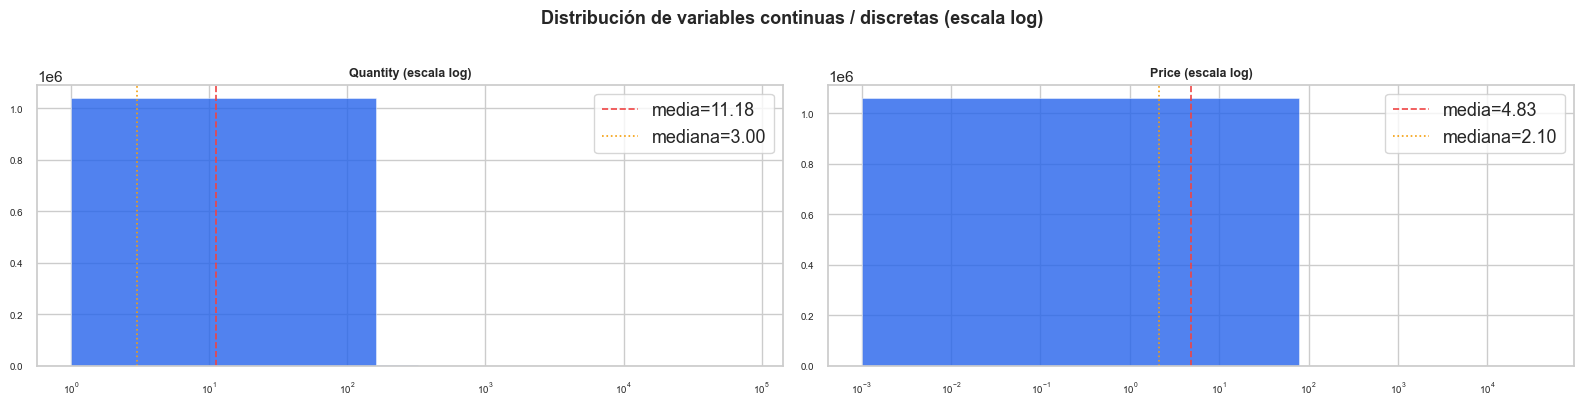

In [11]:
# -------------------------------------------
# Gráfico de variables continuas y discretas
# -------------------------------------------

NUMERIC_RAW = ["Quantity", "Price"]

n_cols = 2
n_rows = -(-len(NUMERIC_RAW) // n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(NUMERIC_RAW):
    ax = axes[i]
    data = df_raw[col].dropna()

    # Evitar problemas con ceros o negativos en escala log
    positive_data = data[data > 0]

    # Histograma
    ax.hist(
        positive_data,
        bins=500,
        color="#2563EB",
        alpha=0.8,
        edgecolor="white",
        linewidth=0.4
    )

    # Escala logarítmica
    ax.set_xscale("log")

    # Título y estilo
    ax.set_title(f"{col} (escala log)", fontsize=9, fontweight="bold")
    ax.set_xlabel("")
    ax.tick_params(labelsize=7)

    # Líneas de media y mediana (solo si son > 0)
    if positive_data.mean() > 0:
        ax.axvline(
            positive_data.mean(),
            color="#EF4444",
            linewidth=1.2,
            linestyle="--",
            label=f"media={positive_data.mean():.2f}"
        )
    if positive_data.median() > 0:
        ax.axvline(
            positive_data.median(),
            color="#F59E0B",
            linewidth=1.2,
            linestyle=":",
            label=f"mediana={positive_data.median():.2f}"
        )

    ax.legend(fontsize=13)

# Ocultar ejes sobrantes
for j in range(len(NUMERIC_RAW), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Distribución de variables continuas / discretas (escala log)", 
             fontweight="bold", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('../output/raw1_distribucion_variables_continuas_discretas_log.png', dpi=300, bbox_inches='tight')
plt.show()

### Distribución de variables continuas/discretas (escala log)

Estas distribuciones muestran cómo se comportan las variables `Quantity` y `Price` después de aplicar una transformación logarítmica.  
La escala log permite visualizar mejor valores muy dispersos y detectar patrones que en escala lineal quedarían ocultos.

- **Quantity** presenta una fuerte asimetría a la derecha: la mayoría de las transacciones tienen cantidades pequeñas, mientras que pocas observaciones alcanzan valores muy altos.  
- **Price** también muestra una distribución sesgada, con precios bajos muy frecuentes y valores altos poco comunes.  
- La diferencia entre **media** y **mediana** en ambas variables confirma la presencia de colas largas y outliers.

Este análisis justifica el uso de transformaciones logarítmicas y técnicas robustas para el modelado.


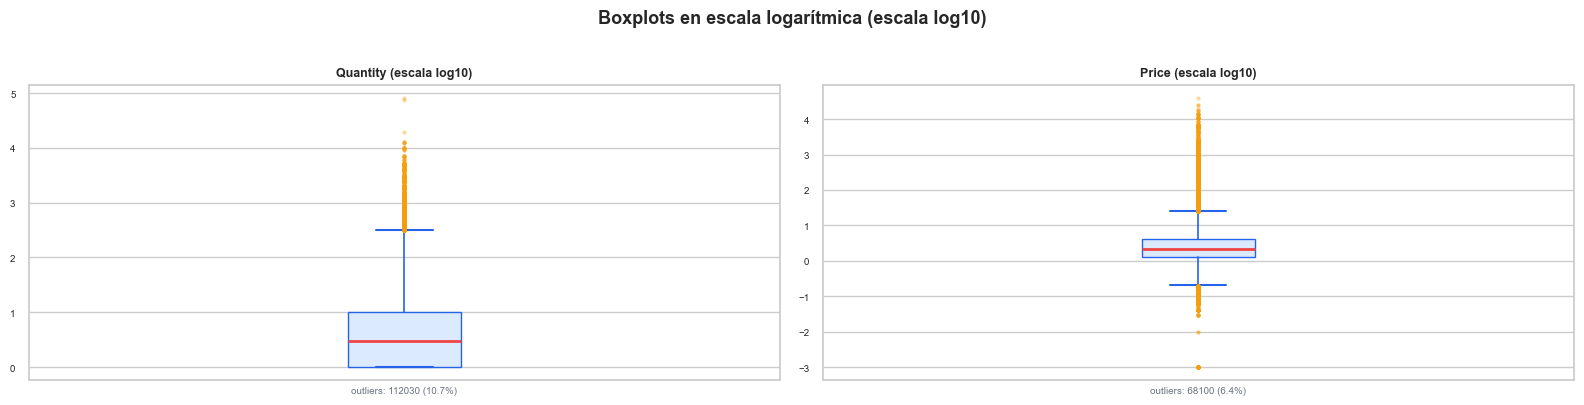

In [12]:
# -------------------------------------------
# Boxplots en escala logarítmica
# -------------------------------------------

NUMERIC_RAW = ["Quantity", "Price"]

n_cols = 2
n_rows = -(-len(NUMERIC_RAW) // n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(NUMERIC_RAW):
    ax = axes[i]
    data = df_raw[col].dropna()

    # Filtrar valores positivos (log no admite 0 o negativos)
    positive_data = data[data > 0]

    # Transformación logarítmica
    log_data = np.log10(positive_data)

    ax.boxplot(
        log_data,
        vert=True,
        patch_artist=True,
        boxprops=dict(facecolor="#DBEAFE", color="#2563EB"),
        medianprops=dict(color="#EF4444", linewidth=2),
        whiskerprops=dict(color="#2563EB", linewidth=1.2),
        capprops=dict(color="#2563EB", linewidth=1.5),
        flierprops=dict(marker="o", markerfacecolor="#F59E0B",
                        markersize=3, alpha=0.4, markeredgewidth=0)
    )

    # Outliers en escala original
    q1, q3 = positive_data.quantile(0.25), positive_data.quantile(0.75)
    iqr = q3 - q1
    n_outliers = ((positive_data < q1 - 1.5 * iqr) | (positive_data > q3 + 1.5 * iqr)).sum()
    pct_outliers = n_outliers / len(positive_data) * 100

    ax.set_title(f"{col} (escala log10)", fontsize=9, fontweight="bold")
    ax.set_xlabel(f"outliers: {n_outliers} ({pct_outliers:.1f}%)",
                  fontsize=7, color="#6B7280")
    ax.tick_params(labelsize=7)
    ax.set_xticks([])

for j in range(len(NUMERIC_RAW), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Boxplots en escala logarítmica (escala log10)",
             fontweight="bold", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('../output/raw2_boxplots_log.png', dpi=300, bbox_inches='tight')
plt.show()


### Boxplots en escala logarítmica

Los boxplots en escala log10 permiten identificar la presencia y magnitud de outliers en `Quantity` y `Price`.

- En **Quantity**, aproximadamente el 10.7% de los valores son outliers, lo que indica una alta variabilidad en las cantidades compradas por transacción.  
- En **Price**, los outliers representan el 6.4%, mostrando que aunque existen precios extremos, su proporción es menor que en Quantity.

Estos resultados refuerzan la necesidad de aplicar transformaciones, winsorización o técnicas robustas para evitar que valores extremos distorsionen el modelo.


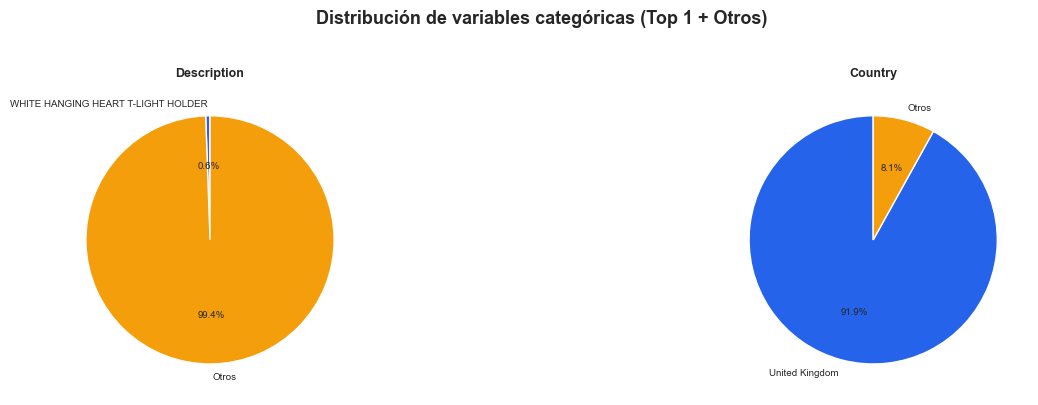

In [13]:
# -------------------------------------------
# Gráfico de variables categóricas (Top 1 + Otros)
# -------------------------------------------
CATEGORICAL_RAW = ["Description", "Country"]

n_cols = 2
n_rows = -(-len(CATEGORICAL_RAW) // n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
axes = axes.flatten()

palette = ["#2563EB","#F59E0B","#22C55E","#EF4444","#8B5CF6",
           "#EC4899","#14B8A6","#F97316","#6366F1","#84CC16"]

TOP_N = 1  # ← la 1 categoría más representativa

for i, col in enumerate(CATEGORICAL_RAW):
    ax = axes[i]

    counts = df_raw[col].value_counts()

    # Top 1 categoría
    top_categories = counts.head(TOP_N)

    # Sumar el resto como "Otros"
    others_sum = counts.iloc[TOP_N:].sum()

    # Construir la serie final
    final_counts = top_categories.copy()
    if others_sum > 0:
        final_counts["Otros"] = others_sum

    wedges, texts, autotexts = ax.pie(
        final_counts.values,
        labels=final_counts.index,
        autopct="%1.1f%%",
        colors=palette[:len(final_counts)],
        startangle=90,
        textprops={"fontsize": 7}
    )

    for at in autotexts:
        at.set_fontsize(7)

    ax.set_title(col, fontsize=9, fontweight="bold")

# Ocultar ejes sobrantes
for j in range(len(CATEGORICAL_RAW), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Distribución de variables categóricas (Top 1 + Otros)",
             fontweight="bold", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('../output/raw3_distribucion_variables_categoricas_top1_otros.png', dpi=300, bbox_inches='tight')
plt.show()


### Distribución de variables categóricas (Top 1 + Otros)

Este análisis resume la concentración de categorías en variables categóricas clave.

- En **Description**, el producto más frecuente representa solo el 0.6% del total, lo que evidencia una alta diversidad de artículos y una distribución extremadamente dispersa.  
- En **Country**, el 91.9% de las transacciones provienen del **United Kingdom**, lo que confirma que el negocio está fuertemente concentrado en un solo mercado.

Esta información es útil para decidir si conviene agrupar categorías, generar dummies o aplicar técnicas de reducción de dimensionalidad.


## 3. Data cleaning

Con el objetivo de construir un dataset consistente y fiable, se procede a:

- Eliminar posibles espacios o caracteres especiales en el nombre de las variables. Estandarizar.
- Eliminar observaciones/filas duplicadas.
- Eliminar nulos de la variable `customer_id`, no necesarios para el análisis.
- Eliminar cancelaciones de la variable `invoice`.
- Eliminar cantidades igual o menor a cero.
- Cambiar variables por tipo de datos acorde a su contenido. Con imputación a la variable `description` que representa porcentaje bajo por 'Unknown'.
- Modificar tipo de dato de str/object a categoria para el ahorro de memoria.

Las transacciones canceladas y cantidades negativas serán eliminadas debido a que no representan compras efectivas del cliente y podrían introducir ruido en el modelo predictivo.

In [14]:
# =========================
# 3. DATA CLEANING
# =========================

# Crear copia de trabajo
df_clean = df_raw.copy()

# --------------------------------------
# Estandarizar nombres de columnas
# --------------------------------------
df_clean.columns = [
    c.strip().lower().replace(' ', '_')
    for c in df_clean.columns
]

# --------------------------------------
# Eliminar duplicados
# --------------------------------------
df_clean = df_clean.drop_duplicates()

print(f"Filas duplicadas: {df_clean.duplicated().sum()}")

# --------------------------------------
# Eliminar customer_id nulos
# --------------------------------------
df_clean = df_clean[df_clean['customer_id'].notnull()]

# --------------------------------------
# Eliminar invoices canceladas
# --------------------------------------
df_clean = df_clean[
    ~df_clean['invoice'].astype(str).str.startswith('C')
]

# --------------------------------------
# Eliminar cantidades inválidas <= cero
# --------------------------------------
df_clean = df_clean[df_clean['quantity'] > 0]

# --------------------------------------
# Eliminar precios inválidos <= cero
# --------------------------------------
df_clean = df_clean[df_clean['price'] > 0]

# --------------------------------------
# Data type corrections
# --------------------------------------
df_clean['description'] = (
    df_clean['description']
    .fillna('Unknown')
    .astype('string')
    .str.strip()
    .str.lower()
    .str.title()
)

df_clean['invoice'] = df_clean['invoice'].astype(int)
df_clean['customer_id'] = df_clean['customer_id'].astype(int)

# --------------------------------------
# Optimizar uso de memoria
# --------------------------------------
mem_before = df_raw.memory_usage(deep=True).sum()

df_clean["country"] = df_clean["country"].astype("category")

mem_after = df_clean.memory_usage(deep=True).sum()

print(f"\nMemoria antes: {mem_before:,}")
print(f"Memoria después : {mem_after:,}")

saving = (mem_before - mem_after) / mem_before * 100

print(f"Ahorro de Memoria(%): {saving:.2f}%")

Filas duplicadas: 0

Memoria antes: 261,153,100
Memoria después : 126,782,352
Ahorro de Memoria(%): 51.45%


## 4. Exploratory Data Analysis

Para mejorar el análisis exploratorio y comprender mejor el comportamiento de compra del cliente, se derivaron varias variables temporales y transaccionales de la fecha de transacción original (`InvoiceDate`).

Estas nuevas variables permiten analizar:

* Patrones de compra estacionales.

* Actividad del cliente por día de la semana y hora del día.

* Evolución de las ventas a lo largo del tiempo.

* Comportamiento de generación de ingresos.

Además, se creó la variable (`Revenue`) como producto de la cantidad y el precio unitario, que representa el valor monetario de cada transacción.

#### Nuevas variables


* **month**: Estacionalidad.

* **month_name**: Interpretación visual.

* **weekday_name**: Hábitos semanales.

* **hour**: Comportamiento horario.

* **time_interval**: Patrones de compra.

* **revenue**: Valor económico.

In [15]:
# ================================
# 4. EXPLORATORY DATA ANALYSIS
# ================================

# Create enriched dataset for EDA
df_features = df_clean.copy()

# --------------------------------------
# Revenue
# --------------------------------------
df_features['revenue'] = df_features['quantity'] * df_features['price']

# --------------------------------------
# Crear columna Mes (en número y nombre) 
# --------------------------------------
df_features["month"] = df_features["invoicedate"].dt.month 
df_features["month_name"] = df_features["invoicedate"].dt.month_name(locale="en_US") 

# -------------------------------------
# Crear día de la semana 
# --------------------------------------
df_features["weekday_name"] = df_features["invoicedate"].dt.day_name(locale="en_US") 

# --------------------------------------
# Crear hora
# --------------------------------------
df_features["hour"] = df_features["invoicedate"].dt.hour

# --------------------------------------
# Columna fin de semana (weekend)
# --------------------------------------
df_features["is_weekend"] = (
    df_features["invoicedate"].dt.weekday >= 5
).astype(int)

# --------------------------------------
#  Crear columna año-mes
# --------------------------------------
df_features["year_month"] = (
    df_features["invoicedate"]
    .dt.to_period("M")
    .astype(str)
)

# --------------------------------------
# Crear intervalos de tiempo 
# --------------------------------------
def clasificar_intervalo(h):
    if 6 <= h < 12:
        return "Morning"
    elif 12 <= h < 18:
        return "Afternoon"
    elif 18 <= h < 24:
        return "Evening"
    else:
        return "Night"

df_features["time_interval"] = df_features["hour"].apply(clasificar_intervalo)

In [16]:
#palette = [
#    "#2563EB","#F59E0B","#22C55E","#EF4444",
#    "#8B5CF6","#EC4899","#14B8A6",
#    "#F97316","#6366F1","#84CC16"
#]

palette = [
    "#C97C5D",  "#D9A566", 
    "#6C9A8B",  "#A67C7B",  
    "#8C7AA9",  "#B08968", 
    "#E07A5F",  "#81B29A", 
]

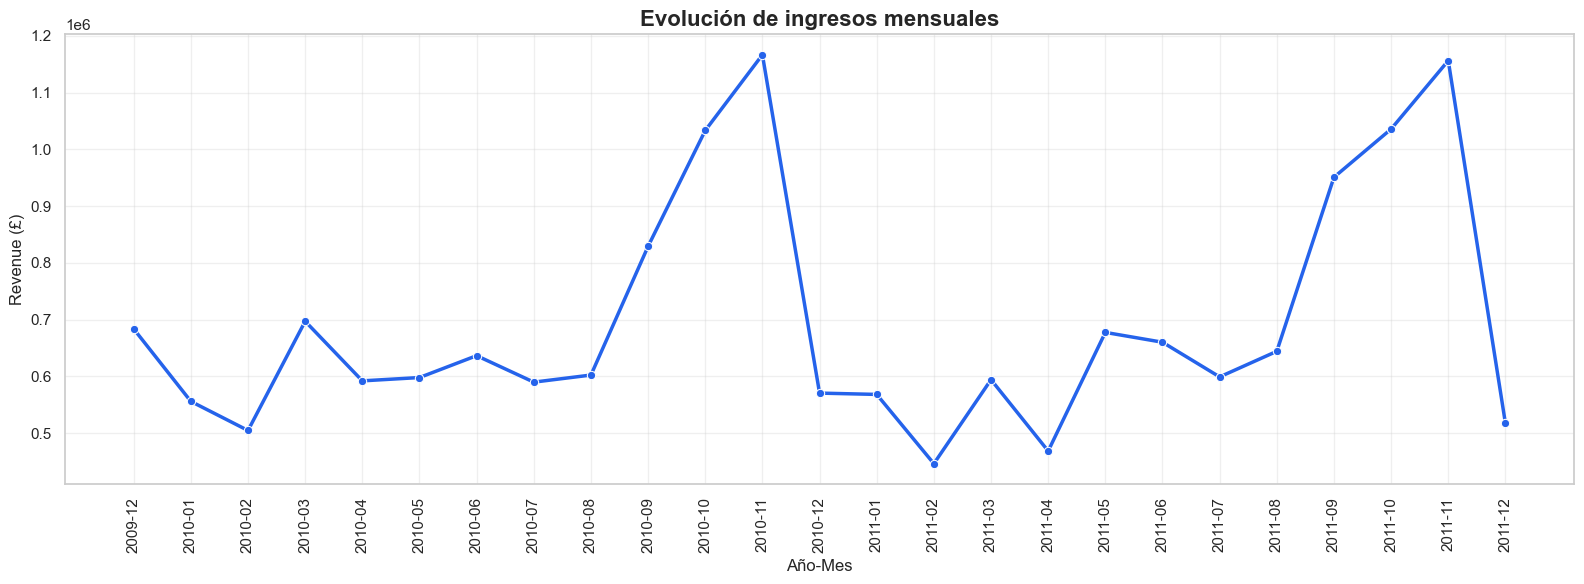

In [17]:
# ==========================================
# Evolución de ingresos mensuales
# ==========================================

monthly_revenue = (
    df_features
    .groupby("year_month")["revenue"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(16,6))

sns.lineplot(
    data=monthly_revenue,
    x="year_month",
    y="revenue",
    marker="o",
    linewidth=2.5,
    color="#2563EB"
)

plt.title(
    "Evolución de ingresos mensuales",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Año-Mes", fontsize=12)
plt.ylabel("Revenue (£)", fontsize=12)

plt.xticks(rotation=90)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../output/features1_evolucion_ingresos_mensuales.png', dpi=300, bbox_inches='tight')
plt.show()

### Evolución de los ingresos mensuales

La evolución de los ingresos mensuales muestra un claro comportamiento de compra estacional durante el período analizado. Los picos significativos en la actividad de ventas sugieren la existencia de períodos comerciales fuertes, probablemente asociados con días festivos y campañas de fin de año.

Esta variabilidad temporal indica que el comportamiento de compra del cliente no es constante a lo largo del tiempo, lo que refuerza la importancia de incorporar variables de frecuencia y actualidad en el modelo predictivo.

C:\Users\Usuario\AppData\Local\Temp\ipykernel_15296\38349447.py:24: UserWarning: The palette list has more values (8) than needed (7), which may not be intended.
  sns.barplot(
C:\Users\Usuario\AppData\Local\Temp\ipykernel_15296\38349447.py:59: UserWarning: The palette list has more values (8) than needed (4), which may not be intended.
  sns.barplot(
C:\Users\Usuario\AppData\Local\Temp\ipykernel_15296\38349447.py:109: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\Usuario\AppData\Local\Temp\ipykernel_15296\38349447.py:109: UserWarning: 
The palette list has fewer values (8) than needed (10) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(


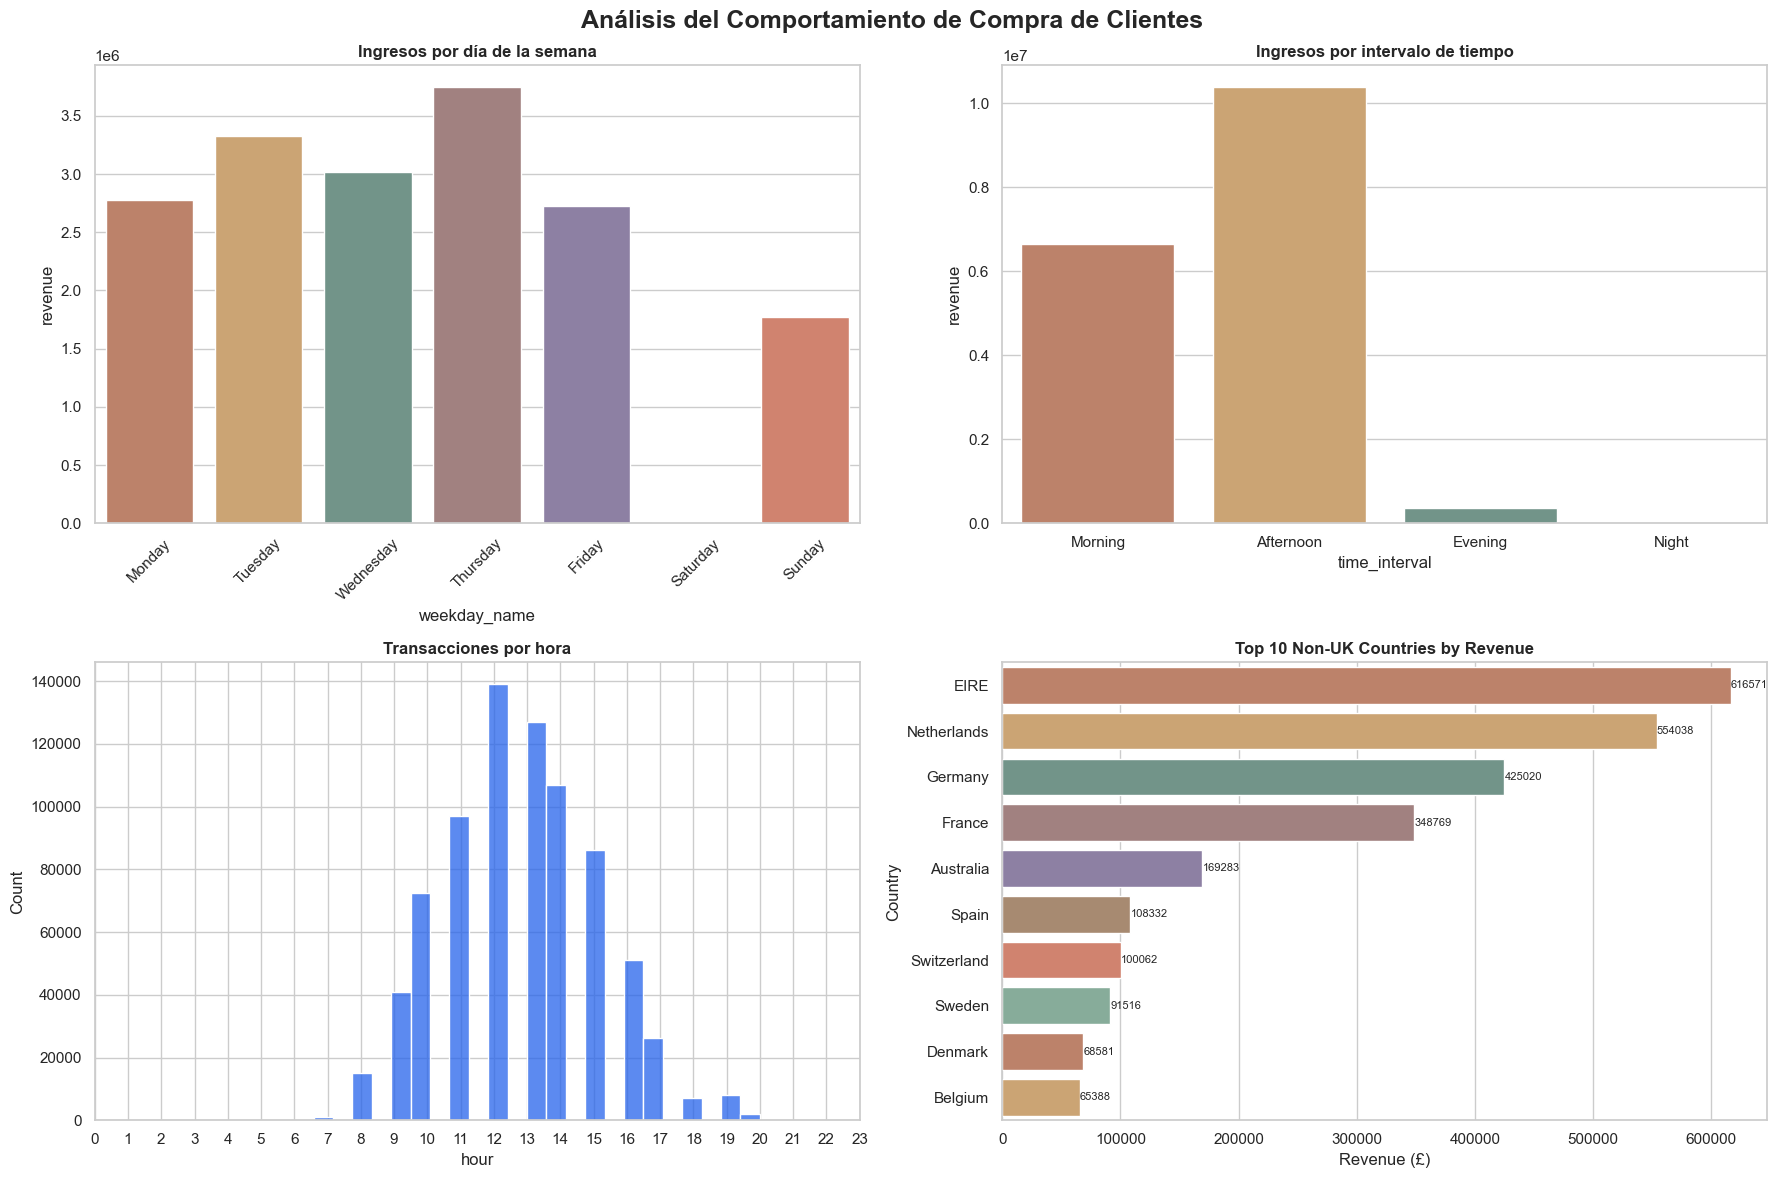

In [18]:
# ==========================================
# Comportamiento de negocio
# # ==========================================

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# ==========================================
# 1. Ingresos por día de la semana
# ==========================================

weekday_order = [
    "Monday","Tuesday","Wednesday",
    "Thursday","Friday","Saturday","Sunday"
]

weekday_revenue = (
    df_features
    .groupby("weekday_name")["revenue"]
    .sum()
    .reindex(weekday_order)
    .reset_index()
)

sns.barplot(
    data=weekday_revenue,
    x="weekday_name",
    y="revenue",
    palette=palette,
    hue="weekday_name",
    ax=axes[0,0]
)

axes[0,0].set_title(
    "Ingresos por día de la semana",
    fontweight="bold"
)

axes[0,0].tick_params(axis='x', rotation=45)

# ==========================================
# 2. Ingresos por intervalo de tiempo
# ==========================================

interval_order = [
    "Morning",
    "Afternoon",
    "Evening",
    "Night"
]

interval_revenue = (
    df_features
    .groupby("time_interval")["revenue"]
    .sum()
    .reindex(interval_order)
    .reset_index()
)

sns.barplot(
    data=interval_revenue,
    x="time_interval",
    y="revenue",
    palette=palette,
    hue="time_interval",        
    ax=axes[0,1]
)

axes[0,1].set_title(
    "Ingresos por intervalo de tiempo",
    fontweight="bold"
)

# ==========================================
# 3. Transacciones por hora
# ==========================================

sns.histplot(
    df_features["hour"],
    bins=24,
    color="#2563EB",
    ax=axes[1,0]
)

axes[1,0].set_title(
    "Transacciones por hora",
    fontweight="bold"
)

axes[1,0].set_xticks(range(0,24))

# ==========================================
# 4. Top países por ingresos (excluyendo UK)
# ==========================================

top_countries = (
    df_features[df_features["country"] != "United Kingdom"]
    .groupby("country", observed=True)["revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

top_countries["country"] = (
    top_countries["country"]
    .astype(str)
)

sns.barplot(
    data=top_countries,
    y="country",
    x="revenue",
    palette=palette[:len(top_countries)],
    ax=axes[1,1]
)

axes[1,1].set_title(
    "Top 10 Non-UK Countries by Revenue",
    fontweight="bold"
)

axes[1,1].set_xlabel("Revenue (£)")
axes[1,1].set_ylabel("Country")

# Etiquetas de valor
for container in axes[1,1].containers:
    axes[1,1].bar_label(
        container,
        fmt='%.0f',
        fontsize=8
    )

# ==========================================
# Diseño global
# ==========================================

plt.suptitle(
    "Análisis del Comportamiento de Compra de Clientes",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()
plt.savefig('../output/features2_comportamiento_negocio.png', dpi=300, bbox_inches='tight')
plt.show()

### → Ingresos por día de la semana

La distribución de los ingresos entre los días de la semana revela patrones de concentración de compras durante la semana laboral. Este comportamiento puede indicar la presencia de clientes B2B o ciclos de compra operativos asociados a los días laborables.

### → Ingresos por intervalo de tiempo

La mayoría de las transacciones se producen durante la mañana y la tarde, lo que sugiere que la actividad de los clientes se concentra principalmente en el horario comercial habitual.


### → Transacciones por hora

La distribución horaria de las transacciones destaca los periodos de mayor actividad comercial a lo largo del día. Comprender estos picos operativos puede ayudar a optimizar las campañas de marketing y las estrategias de interacción con el cliente.


### → Principales países por ingresos

El Reino Unido domina de forma abrumadora la generación total de ingresos. Para comprender mejor el comportamiento de los clientes internacionales, el análisis excluye las transacciones en el Reino Unido y se centra en los principales mercados fuera de este país con la idea de influir en las estrategias de fidelización de clientes y en el comportamiento de compra para el resto de mercado.

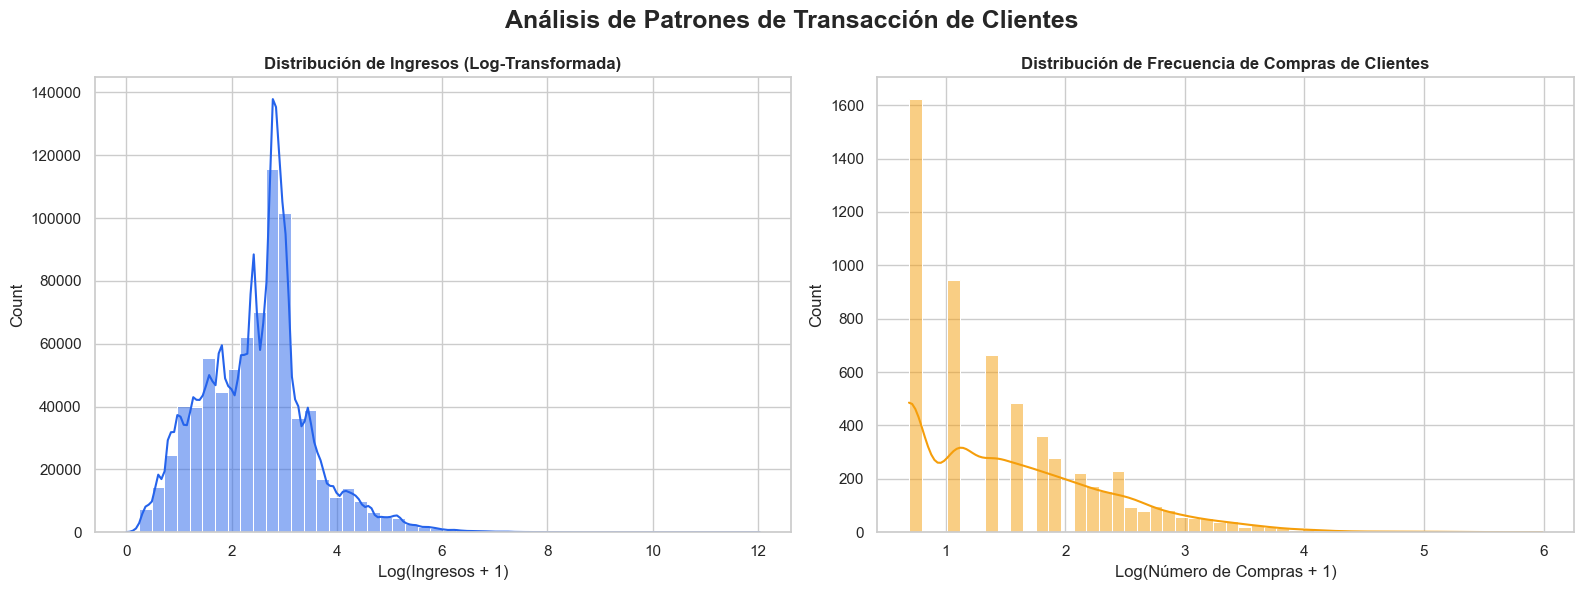

In [19]:
# ==========================================
# Comportamiento de compra de clientes
# ==========================================

fig, axes = plt.subplots(1, 2, figsize=(16,6))

# ==========================================
# 1. Distribución de ingresos (log-transformada)
# ==========================================

sns.histplot(
    np.log1p(df_features["revenue"]),
    bins=50,
    kde=True,
    color="#2563EB",
    ax=axes[0]
)

axes[0].set_title(
    "Distribución de Ingresos (Log-Transformada)",
    fontweight="bold"
)

axes[0].set_xlabel("Log(Ingresos + 1)")

# ==========================================
# 2. Frecuencia de Compras de Clientes
# ==========================================

customer_frequency = (
    df_features
    .groupby("customer_id")["invoice"]
    .nunique()
)

sns.histplot(
    np.log1p(customer_frequency),
    bins=50,
    kde=True,
    color="#F59E0B",
    ax=axes[1]
)

axes[1].set_title(
    "Distribución de Frecuencia de Compras de Clientes",
    fontweight="bold"
)

axes[1].set_xlabel(
    "Log(Número de Compras + 1)"
)

# ==========================================
# Diseño global
# ==========================================

plt.suptitle(
    "Análisis de Patrones de Transacción de Clientes",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()
plt.savefig('../output/features3_comportamiento_clientes.png', dpi=300, bbox_inches='tight')
plt.show()

### → Distribución de ingresos

La distribución de ingresos presenta una marcada asimetría positiva, lo que indica la presencia de un número reducido de transacciones de gran volumen y numerosas compras de bajo valor. Este comportamiento es común en el sector minorista y sugiere la necesidad de realizar transformaciones logarítmicas durante el modelado.


### → Frecuencia de compra del cliente

La frecuencia de compra del cliente muestra que la mayoría de los clientes realizan relativamente pocas compras, mientras que un grupo menor presenta un comportamiento de compra recurrente significativo. Este desequilibrio respalda la relevancia de desarrollar un modelo de predicción de recompra del cliente.

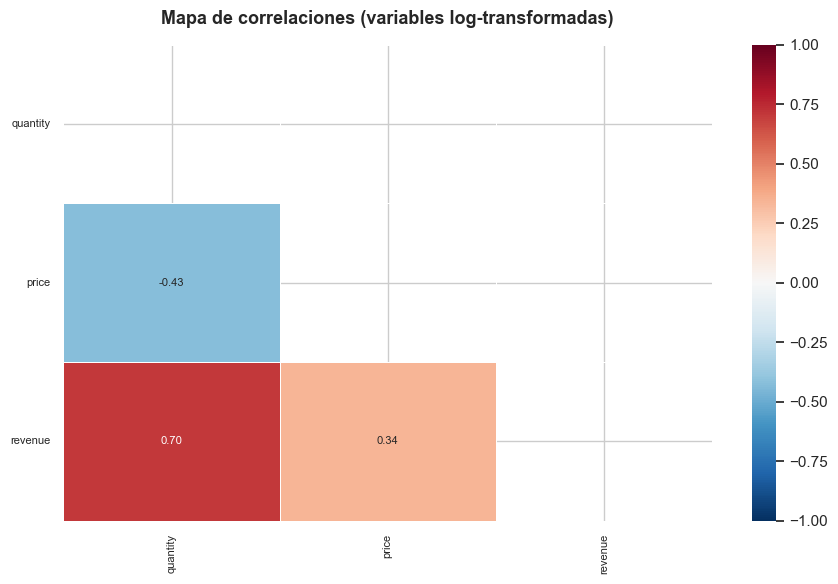

Pares con correlación alta (|r| > 0.5):


,var1,var2,r
1,revenue,quantity,0.703282


In [20]:
# -------------------------------------------
# Transformación logarítmica para correlaciones
# -------------------------------------------

numeric_cols = ["quantity", "price", "revenue"]

# Filtrar valores positivos (log no admite 0 o negativos)
df_log = df_features[numeric_cols].copy()
for col in numeric_cols:
    df_log[col] = df_log[col].where(df_log[col] > 0)  # mantener NaN si <= 0
    df_log[col] = np.log10(df_log[col])

# Matriz de correlación en escala log
corr_matrix = df_log.corr()

# Máscara triángulo superior
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(
    corr_matrix,
    mask      = mask,
    annot     = True,
    fmt       = ".2f",
    cmap      = "RdBu_r",
    center    = 0,
    vmin      = -1,
    vmax      = 1,
    linewidths= 0.5,
    linecolor = "white",
    annot_kws = {"size": 8},
    ax        = ax
)

ax.set_title("Mapa de correlaciones (variables log-transformadas)", 
             fontweight="bold", fontsize=13, pad=15)
ax.tick_params(axis="x", rotation=90, labelsize=8)
ax.tick_params(axis="y", rotation=0,  labelsize=8)

plt.tight_layout()
plt.savefig('../output/features4_correlacion_variables_log.png', dpi=300, bbox_inches='tight')
plt.show()

# Pares con correlación alta
print("Pares con correlación alta (|r| > 0.5):")
corr_pairs = (
    corr_matrix.where(np.tril(np.ones(corr_matrix.shape), k=-1).astype(bool))
    .stack()
    .reset_index()
)
corr_pairs.columns = ["var1","var2","r"]
corr_pairs[corr_pairs["r"].abs() > 0.5].sort_values("r", ascending=False)

### Mapa de correlaciones (variables log-transformadas)

El mapa de calor muestra las correlaciones entre `Quantity`, `Price` y `Revenue` después de aplicar transformaciones logarítmicas.

- **Quantity y Revenue** presentan una correlación positiva fuerte (0.70), lo cual es esperable ya que el ingreso depende directamente de la cantidad vendida.  
- **Price y Revenue** tienen una correlación moderada (0.34), indicando que el precio influye, pero en menor medida que la cantidad.  
- **Quantity y Price** muestran una correlación negativa (-0.43), lo que sugiere que productos más baratos tienden a venderse en mayores cantidades.

Este análisis ayuda a entender la estructura del negocio y a anticipar qué variables podrían tener mayor impacto en el modelo.


## 5. Feature engineering

Para predecir la probabilidad de recompra del cliente, el conjunto de datos transaccionales se transformó en un conjunto de datos analíticos a nivel de cliente.

Se implementó una estrategia de división temporal utilizando una fecha límite. Las transacciones anteriores a la fecha límite se utilizaron para generar variables explicativas (features), mientras que las posteriores se utilizaron para construir la variable objetivo.

El proceso de feature engineering se centró en capturar el comportamiento de compra del cliente mediante métricas relacionadas con RFM e indicadores de comportamiento adicionales.

### Principales características diseñadas

* **Recencia**: número de días desde la última compra del cliente.

* **Frecuencia**: número de transacciones de compra únicas realizadas por el cliente.

* **Ingresos monetarios**: ingresos totales generados por el cliente.

* **Valor monetario promedio**: valor monetario promedio por transacción.

* **Productos únicos**: número de productos diferentes comprados.

* **Cantidad total**: número total de artículos comprados.

* **Antigüedad del cliente**: número de días entre la primera y la última compra observada.
* **Días promedio entre compras**: periodicidad promedio de las compras.

* **Características de los países**: los principales países se codificaron mediante dummy variables.

Estas variables buscan capturar la interacción con el cliente, la intensidad de compra, la consistencia de las compras y el valor comercial, factores altamente relevantes para predecir el comportamiento de recompra.


In [21]:
# ================================
# 5. FEATURE ENGINEERING
# ================================

# 5.1 Temporal Split

# --------------------------------------
# Cutoff - fecha de corte
# --------------------------------------
cutoff_date = pd.to_datetime("2011-06-01")

# --------------------------------------
# Transacciones históricas 
# --------------------------------------
historical_df = df_features[
    df_features["invoicedate"] < cutoff_date
].copy()

# --------------------------------------
# Futuras transacciones 
# --------------------------------------
future_df = df_features[
    df_features["invoicedate"] >= cutoff_date
].copy()

# 5.2 Características a nivel cliente (RFM + adicionales)
customer_features = pd.DataFrame()

customer_features["customer_id"] = (
    historical_df["customer_id"].unique()
)

customer_features = customer_features.set_index("customer_id")

# 5.3 Recency
last_purchase = (
    historical_df
    .groupby("customer_id")["invoicedate"]
    .max()
)

customer_features["recency"] = (
    cutoff_date - last_purchase
).dt.days

# 5.4 Frecuency
customer_features["frequency"] = (
    historical_df
    .groupby("customer_id")["invoice"]
    .nunique()
)

# 5.5 Monetary
customer_features["monetary"] = (
    historical_df
    .groupby("customer_id")["revenue"]
    .sum()
)

# 5.6 Ticket medio
customer_features["avg_ticket"] = (
    customer_features["monetary"] /
    customer_features["frequency"]
)

# 5.7 Productos únicos
customer_features["unique_products"] = (
    historical_df
    .groupby("customer_id")["stockcode"]
    .nunique()
)

# 5.8 Cantidad total de productos comprados por cliente
customer_features["total_quantity"] = (
    historical_df
    .groupby("customer_id")["quantity"]
    .sum()
)

# 5.9 Tenencia del cliente
customer_tenure = (
    historical_df
    .groupby("customer_id")["invoicedate"]
    .agg(["min", "max"])
)

customer_features["customer_tenure"] = (
    customer_tenure["max"] -
    customer_tenure["min"]
).dt.days

# 5.10 Días promedio entre compras
purchase_span = (
    historical_df
    .groupby("customer_id")["invoicedate"]
    .agg(["min", "max", "nunique"])
)

customer_features["avg_days_between_purchases"] = (
    (
        purchase_span["max"] -
        purchase_span["min"]
    ).dt.days /
    (purchase_span["nunique"] - 1)
)

customer_features[
    "avg_days_between_purchases"
] = customer_features[
    "avg_days_between_purchases"
].fillna(0)

# 5.11 País top 5 y sexto agrupado en otros (a nivel cliente)
top_countries = (
    historical_df["country"]
    .value_counts()
    .nlargest(5)
    .index
)

customer_country = (
    historical_df
    .groupby("customer_id")["country"]
    .first()
)

customer_country = customer_country.apply(
    lambda x: x if x in top_countries else "Other"
)

country_dummies = pd.get_dummies(
    customer_country,
    prefix="country"
)

customer_features = customer_features.join(
    country_dummies
)


## 6. Target Construction

La variable objetivo se construyó utilizando las transacciones futuras de los clientes ocurridas después de la fecha límite.

Los clientes que realizaron al menos una compra adicional después de la fecha límite se clasificaron como:

* **1 → Comprador recurrente - Rebuyer**
* **0 → No comprador recurrente - Non Rebuyer**

Esta configuración de aprendizaje supervisado permite que el modelo aprenda patrones de comportamiento históricos asociados con la probabilidad de recompra futura.

In [22]:
# ================================
# 6. TARGET CONSTRUCTION
# ================================

# --------------------------------
# Clientes que recompraron
# --------------------------------
future_customers = (
    future_df["customer_id"]
    .unique()
)

# --------------------------------
# Crear target
# --------------------------------
customer_features["is_rebuyer"] = (
    customer_features.index
    .isin(future_customers)
    .astype(int)
)

# --------------------------------
# Ver distribución
# --------------------------------
customer_features["is_rebuyer"].value_counts()

is_rebuyer
1    2602
0    2331
Name: count, dtype: int64

In [23]:
# --------------------------------
# Tasa de recompra
# --------------------------------
repurchase_rate = (
    customer_features["is_rebuyer"]
    .mean()
)

print(
    f"Tasa de recompra: {repurchase_rate:.2%}"
)

Tasa de recompra: 52.75%


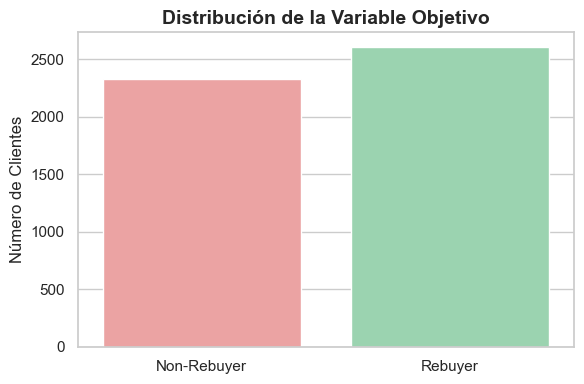

In [24]:
# ==========================================
# Target Distribution
# ==========================================

target_dist = (
    customer_features["is_rebuyer"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(6,4))

sns.barplot(
    x=["Non-Rebuyer", "Rebuyer"],
    y=target_dist.values,
    hue=["Non-Rebuyer", "Rebuyer"],
    palette=["#F79797", "#91DDAD"]
)

plt.title(
    "Distribución de la Variable Objetivo",
    fontsize=14,
    fontweight="bold"
)

plt.ylabel("Número de Clientes")
plt.xlabel("")

plt.tight_layout()
plt.savefig('../output/features5_distribucion_target.png', dpi=300, bbox_inches='tight')
plt.show()

### Distribución de la variable objetivo (`is_rebuyer`)

La variable objetivo muestra una distribución relativamente equilibrada:

- **Rebuyer**: clientes que realizaron al menos una recompra.  
- **Non-Rebuyer**: clientes que no volvieron a comprar.

Aunque existe una ligera mayoría de clientes que recompran, la distribución es lo suficientemente balanceada como para no requerir técnicas agresivas de resampling.  
Este equilibrio facilita el entrenamiento de modelos de clasificación sin introducir sesgos significativos.



## 7. MODELING

### → Problem Framing

El problema se formula como una clasificación binaria supervisada, donde:

1 (`is_rebuyer`) → el cliente realiza recompra en el periodo futuro

0 → el cliente no vuelve a comprar

El dataset presenta un ligero balance de clases (52.75% positivos), por lo que no es necesario aplicar técnicas agresivas de rebalancing, aunque se mantendrá class_weight en algunos modelos como control.

### → Train / Test Split

Dado que el problema es de naturaleza temporal, se evita el random split para prevenir data leakage.

### → Métricas de Evaluación

Se evaluarán los modelos usando:

AUC ROC → capacidad de ranking del modelo
Accuracy → performance global
Precision → calidad de predicción positiva
Recall → cobertura de clientes que realmente recompran

### → Modelo Base 1 - Logistic Regression

Se utiliza como baseline por su interpretabilidad y robustez en problemas lineales.

### → Modelo 2: Random Forest

Modelo no lineal basado en ensamblado de árboles, útil para capturar interacciones complejas.

### → Modelo 3: XGBoost

Modelo de boosting altamente eficiente, generalmente el más fuerte en problemas tabulares.

In [25]:
# ===========================================
# 7. Train / Test Split (Temporal Validación)
# ===========================================
from sklearn.model_selection import train_test_split

X = customer_features.drop(columns=["is_rebuyer"])
y = customer_features["is_rebuyer"]

# Split estratificado (manteniendo distribución)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [26]:
# =======================
# Metricas de evaluación
# =======================
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score
)

In [27]:
# =====================================
# Modelo Baseline - Logistic Regression
# =====================================
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

log_reg = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

log_reg.fit(X_train, y_train)

y_pred_lr = log_reg.predict(X_test)
y_proba_lr = log_reg.predict_proba(X_test)[:, 1]


results = {}

# -------------------------------
# Evaluación del modelo
# -------------------------------  
results["Logistic Regression"] = {
    "AUC": roc_auc_score(y_test, y_proba_lr),
    "Accuracy": accuracy_score(y_test, y_pred_lr),
    "Precision": precision_score(y_test, y_pred_lr),
    "Recall": recall_score(y_test, y_pred_lr)
}

In [28]:
# =====================================
# Modelo Random Forest
# =====================================
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

# -------------------------------
# Evaluación del modelo
# -------------------------------  
results["Random Forest"] = {
    "AUC": roc_auc_score(y_test, y_proba_rf),
    "Accuracy": accuracy_score(y_test, y_pred_rf),
    "Precision": precision_score(y_test, y_pred_rf),
    "Recall": recall_score(y_test, y_pred_rf)
}

In [29]:
# =====================================
# Modelo XGBoost
# =====================================
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)
y_proba_xgb = xgb.predict_proba(X_test)[:, 1]

# -------------------------------
# Evaluación del modelo
# -------------------------------  
results["XGBoost"] = {
    "AUC": roc_auc_score(y_test, y_proba_xgb),
    "Accuracy": accuracy_score(y_test, y_pred_xgb),
    "Precision": precision_score(y_test, y_pred_xgb),
    "Recall": recall_score(y_test, y_pred_xgb)
}

### 7.1 Comparación de Modelos

In [30]:
# Resultados ordenados por AUC
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values(by="AUC", ascending=False)

results_df

,AUC,Accuracy,Precision,Recall
Logistic Regression,0.792620,0.717325,0.741036,0.714012
XGBoost,0.778451,0.704154,0.720617,0.717850
Random Forest,0.777442,0.696049,0.724138,0.685221


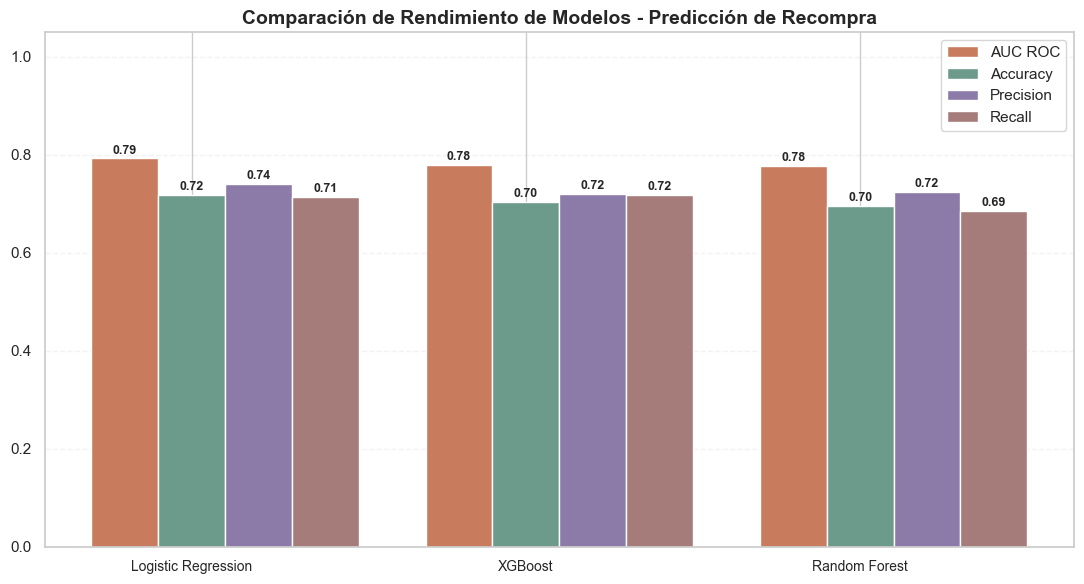

In [31]:
# Gráfico de comparación de modelos
metrics = results_df.copy()

x = np.arange(len(metrics.index))
width = 0.20

plt.figure(figsize=(11,6))

bars1 = plt.bar(x - width, metrics["AUC"], width, label="AUC ROC", color="#C97C5D")
bars2 = plt.bar(x, metrics["Accuracy"], width, label="Accuracy", color="#6C9A8B")
bars3 = plt.bar(x + width, metrics["Precision"], width, label="Precision", color="#8C7AA9")
bars4 = plt.bar(x + 2*width, metrics["Recall"], width, label="Recall", color="#A67C7B")

# -----------------------
# Etiquetas encima de barras
# -----------------------
def add_labels(bars):
    for b in bars:
        height = b.get_height()
        plt.text(
            b.get_x() + b.get_width()/2,
            height + 0.01,
            f"{height:.2f}",
            ha="center",
            fontsize=9,
            fontweight="bold"
        )

add_labels(bars1)
add_labels(bars2)
add_labels(bars3)
add_labels(bars4)

# -----------------------
# Estilo y diseño
# -----------------------
plt.title("Comparación de Rendimiento de Modelos - Predicción de Recompra",
          fontsize=14, fontweight="bold")

plt.xticks(x, metrics.index, fontsize=10)
plt.ylim(0, 1.05)

plt.grid(axis="y", linestyle="--", alpha=0.25)
plt.legend()
plt.tight_layout()
plt.savefig('../output/model1_comparacion.png', dpi=300, bbox_inches='tight')
plt.show()

### Comparación de rendimiento entre modelos

Este gráfico compara el desempeño de Logistic Regression, XGBoost y Random Forest utilizando cuatro métricas clave: AUC ROC, Accuracy, Precision y Recall.

- **Logistic Regression** obtiene el mejor AUC (0.79) y la mayor precisión, mostrando un equilibrio sólido entre sensibilidad y especificidad.  
- **XGBoost** y **Random Forest** presentan métricas similares entre sí, con un rendimiento ligeramente inferior al modelo lineal.  
- La consistencia entre las métricas indica que no existe sobreajuste significativo y que los modelos capturan patrones reales del comportamiento de recompra.

Este análisis permite seleccionar el modelo más adecuado según los objetivos del negocio: maximizar discriminación (AUC) o priorizar precisión/recall.


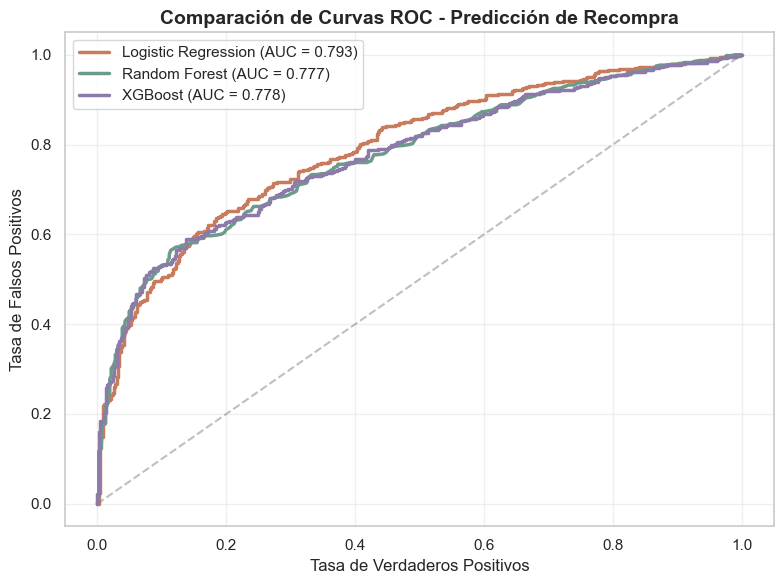

In [32]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(8,6))

models = {
    "Logistic Regression": y_proba_lr,
    "Random Forest": y_proba_rf,
    "XGBoost": y_proba_xgb
}

colors = {
    "Logistic Regression": "#C97C5D",
    "Random Forest": "#6C9A8B",
    "XGBoost": "#8C7AA9"
}

for name, proba in models.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC = {roc_auc:.3f})",
        linewidth=2.5,
        color=colors[name]
    )

# baseline
plt.plot([0,1], [0,1], linestyle="--", color="gray", alpha=0.5)

plt.title("Comparación de Curvas ROC - Predicción de Recompra",
          fontsize=14, fontweight="bold")

plt.xlabel("Tasa de Verdaderos Positivos")
plt.ylabel("Tasa de Falsos Positivos")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../output/model2_curvas_roc_comparacion.png', dpi=300, bbox_inches='tight')
plt.show()

### Curvas ROC comparadas entre modelos

Las curvas ROC permiten evaluar la capacidad de cada modelo para distinguir entre clientes que recompran y los que no.

- **Logistic Regression** muestra la curva más alejada de la diagonal aleatoria, con un AUC de 0.793, lo que indica el mejor desempeño global.  
- **XGBoost** y **Random Forest** presentan curvas muy similares entre sí, con AUC cercanos a 0.78.  
- La diagonal punteada representa un clasificador aleatorio; cuanto más se aleja la curva hacia la esquina superior izquierda, mejor es el modelo.

Este análisis confirma que los tres modelos son útiles, pero Logistic Regression ofrece la mejor capacidad discriminativa.


## 8. Búsqueda de Hiperparámetros con Optuna

La optimización de hiperparámetros es un paso crítico para maximizar el rendimiento de los modelos. En este proyecto utilizamos Optuna, una librería moderna y eficiente basada en Bayesian Optimization que permite encontrar configuraciones óptimas de forma automática y rápida.

Entrenaremos y optimizaremos tres modelos:

* **Logistic Regression**
* **Random Forest**
* **XGBoost**

El objetivo de la optimización será maximizar el AUC, ya que es la métrica más adecuada para problemas de clasificación con clases balanceadas o ligeramente desbalanceadas.

In [33]:
import optuna
from sklearn.model_selection import cross_val_score

def objective(trial):
    model_name = trial.suggest_categorical("model", ["logreg", "rf", "xgb"])

    if model_name == "logreg":
        C = trial.suggest_float("C", 1e-3, 10.0, log=True)
        model = LogisticRegression(
            C=C,
            max_iter=1000,
            class_weight="balanced"
        )

    elif model_name == "rf":
        n_estimators = trial.suggest_int("n_estimators", 200, 800)
        max_depth = trial.suggest_int("max_depth", 4, 20)
        model = RandomForestClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            random_state=42,
            n_jobs=-1,
            class_weight="balanced"
        )

    else:  # XGBoost
        params = {
            "n_estimators": trial.suggest_int("n_estimators", 200, 600),
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3),
            "max_depth": trial.suggest_int("max_depth", 3, 10),
            "subsample": trial.suggest_float("subsample", 0.5, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
            "eval_metric": "logloss",
            "random_state": 42
        }
        model = XGBClassifier(**params)

    auc = cross_val_score(
        model, X_train, y_train,
        scoring="roc_auc",
        cv=3,
        n_jobs=-1
    ).mean()

    return auc

X_train = X_train.astype({col: "object" for col in X_train.select_dtypes(include=["string"]).columns})
X_test = X_test.astype({col: "object" for col in X_test.select_dtypes(include=["string"]).columns})


In [34]:
# ------------------------------
# Ejecutar optimización
# ------------------------------
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50)

print("Mejores hiperparámetros:", study.best_params)
print("Mejor AUC:", study.best_value)



[I 2026-06-06 17:30:54,971] A new study created in memory with name: no-name-eb212659-4cda-4488-bdfc-8e36dc03dd54
[I 2026-06-06 17:30:59,683] Trial 0 finished with value: 0.8035829153716585 and parameters: {'model': 'logreg', 'C': 8.399280088537912}. Best is trial 0 with value: 0.8035829153716585.
[I 2026-06-06 17:31:02,820] Trial 1 finished with value: 0.8037058090727222 and parameters: {'model': 'logreg', 'C': 0.011587869794649803}. Best is trial 1 with value: 0.8037058090727222.
[I 2026-06-06 17:31:03,994] Trial 2 finished with value: 0.7548498502435459 and parameters: {'model': 'xgb', 'n_estimators': 571, 'learning_rate': 0.23753609944812817, 'max_depth': 10, 'subsample': 0.5577382785230156, 'colsample_bytree': 0.6486151804302611}. Best is trial 1 with value: 0.8037058090727222.
[I 2026-06-06 17:31:07,333] Trial 3 finished with value: 0.7887268542526885 and parameters: {'model': 'rf', 'n_estimators': 662, 'max_depth': 20}. Best is trial 1 with value: 0.8037058090727222.
[I 2026-06-

Mejores hiperparámetros: {'model': 'xgb', 'n_estimators': 286, 'learning_rate': 0.011739064647053023, 'max_depth': 3, 'subsample': 0.8570876449065747, 'colsample_bytree': 0.5585054569739027}
Mejor AUC: 0.8116481801100267


In [35]:
# -------------------------------------------------
# Entrenar modelo final con mejores hiperparámetros
# -------------------------------------------------
best_params = study.best_params

if best_params["model"] == "logreg":
    final_model = LogisticRegression(
        C=best_params["C"],
        max_iter=1000,
        class_weight="balanced"
    )

elif best_params["model"] == "rf":
    final_model = RandomForestClassifier(
        n_estimators=best_params["n_estimators"],
        max_depth=best_params["max_depth"],
        random_state=42,
        n_jobs=-1,
        class_weight="balanced"
    )

else:
    final_model = XGBClassifier(
        **{k: v for k, v in best_params.items() if k != "model"},
        eval_metric="logloss",
        random_state=42
    )

final_model.fit(X_train, y_train)


,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.5585054569739027
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


## 9. Explicabilidad del Modelo con DALEX

La explicabilidad es fundamental en proyectos de Machine Learning aplicados al negocio retail, ya que permite:

* **Entender qué impulsa la recompra**

* **Justificar decisiones ante stakeholders**

* **Detectar sesgos o comportamientos inesperados**

* **Aumentar la confianza en el modelo**

Para este proyecto utilizamos DALEX, una librería especializada en explicabilidad global y local.

In [36]:
#----------------------------
# Crear explicador con DALEX
#----------------------------
import dalex as dx

# para DALEX, es importante que los datos sean numéricos (o codificados adecuadamente)
X_train_final = X_train.astype(float)
X_test_final = X_test.astype(float)

final_model.fit(X_train_final, y_train)

explainer = dx.Explainer(
    final_model,
    X_test_final,
    y_test,
    label="Modelo de Recompra - Optimizado"
)

Preparation of a new explainer is initiated

  -> data              : 987 rows 14 cols
  -> target variable   : Parameter 'y' was a pandas.Series. Converted to a numpy.ndarray.
  -> target variable   : 987 values
  -> model_class       : xgboost.sklearn.XGBClassifier (default)
  -> label             : Modelo de Recompra - Optimizado
  -> predict function  : <function yhat_proba_default at 0x000002DDA4C12090> will be used (default)
  -> predict function  : Accepts pandas.DataFrame and numpy.ndarray.
  -> predicted values  : min = 0.0951, mean = 0.52, max = 0.952
  -> model type        : classification will be used (default)
  -> residual function : difference between y and yhat (default)
  -> residuals         : min = -0.943, mean = 0.00791, max = 0.905
  -> model_info        : package xgboost

A new explainer has been created!


In [50]:
# Importancia global de variables
fi = explainer.model_parts()

# Obtener la figura real de Plotly
fig = fi.plot(show=False)

# Mostrar en notebook
fig.show()

# Guardar en archivo
fig.write_image('../output/dalex1_importancia_variables.png', scale=4)

### Importancia global de variables (DALEX)

Este gráfico muestra la importancia de cada variable en el modelo optimizado, medida mediante *drop-out loss*.

- **Recency** es, con diferencia, la variable más influyente: cuanto más reciente es la última compra, mayor es la probabilidad de recompra.  
- **Frequency**, **total_quantity** y **avg_days_between_purchases** también aportan información relevante, aunque en menor magnitud.  
- Las variables de país tienen impacto prácticamente nulo, lo que indica que la geografía no es un factor determinante en la recompra dentro de este dataset.

Este análisis ayuda a comprender qué factores impulsan el comportamiento de recompra y facilita la toma de decisiones estratégicas.


In [49]:
# Efectos individuales (ALE/PDP)
profile = explainer.model_profile(variables=["recency"], type="accumulated")
fig = profile.plot(show=False)
fig.show()
fig.write_image('../output/dalex2_efectos_individuales_recency.png', scale=4)



Calculating accumulated dependency: 100%|██████████| 1/1 [00:00<00:00,  7.93it/s]


### Efecto individual de la variable *recency* (DALEX)

El perfil agregado muestra cómo cambia la predicción del modelo a medida que varía la variable **recency**.

- A valores bajos de recency (última compra reciente), la probabilidad de recompra es alta.  
- A medida que aumenta el número de días desde la última compra, la probabilidad disminuye de forma progresiva.  
- La curva confirma un comportamiento típico en retail: clientes inactivos por largos periodos tienen menor probabilidad de volver a comprar.

Este análisis permite interpretar el modelo de forma intuitiva y validar que su comportamiento es coherente con la lógica del negocio.


In [ ]:
# Explicación local (LIME-like)
idx = 10  # cliente ejemplo
local_exp = explainer.predict_parts(X_test_final.iloc[idx], type="break_down")
fig = local_exp.plot(show=False)
fig.show()
fig.write_image('../output/dalex3_explicacion_local.png', scale=4)



### Explicación local de una predicción (Break Down)

Este gráfico descompone la predicción de un cliente específico, mostrando cómo cada variable contribuye a aumentar o disminuir la probabilidad final de recompra.

- El **intercepto** representa la predicción base del modelo antes de considerar características individuales.  
- Variables como **recency**, **frequency**, **total_quantity** y **monetary** empujan la predicción hacia arriba, indicando señales fuertes de recompra.  
- Algunas variables aportan contribuciones negativas menores, ajustando la predicción final.  
- El resultado final es una probabilidad alta (≈0.90), explicada de manera transparente por los factores del cliente.

Este tipo de análisis es clave para justificar decisiones personalizadas en marketing o CRM.


In [52]:
# Evaluación de desempeño del modelo
mp = explainer.model_performance()
fig = mp.plot(show=False)
fig.show()
fig.write_image('../output/dalex4_desempeno_modelo.png', scale=4)



### Distribución acumulada inversa de los residuos

Este gráfico muestra la distribución acumulada inversa de los valores absolutos de los residuos del modelo.

- Un porcentaje alto de observaciones presenta errores pequeños, lo que indica un buen ajuste general.  
- A medida que aumenta el valor del residuo, la proporción de casos que lo superan disminuye rápidamente.  
- La forma suave y decreciente de la curva sugiere que el modelo no presenta errores extremos frecuentes.

Este análisis complementa las métricas tradicionales y permite evaluar la estabilidad del modelo en diferentes rangos de error.
